# PCA MNIST

## Importación de bibliotecas.
Primero importamos las bibliotecas que vamos a necesitar:
- idx2numpy: permite leer los archivos que se proporcionan en el Dataset de Kaggle, y lo pone en un Numpy Array.
- Pandas : Nos va a permitir trabajar con dataframes.
- Seaborn y Matplotlib: para graficación.
- sklearn.decomposition: la utilizamos para utilizar PCA.

In [1]:
# Importar las bibliotecas necesarias
import os
import idx2numpy
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## Procesamiento de los archivos descargados de Kaggle

In [2]:
file_path = './mnist_ds//t10k-images.idx3-ubyte'
images = idx2numpy.convert_from_file(file_path)
labels = idx2numpy.convert_from_file('./mnist_ds/t10k-labels.idx1-ubyte')

In [3]:
labels

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

In [4]:
images.shape[0]  #Aquí observamos la cantidad de elementosd que había en el archivo t10k-images 

10000

Hcemos un Reshape coin el método reshape() de NumPy

In [5]:
img_flat = images.reshape(images.shape[0], 28 * 28)

Con esto corroboramos que el aplanamiento 
de la imagen se haya hecho de forma correcta.

In [6]:
img_flat.shape[1]    

784

In [7]:
img_flat[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [8]:
column_names = [] # Lista para nombrar las columnas

In [9]:
for i in range (28*28):
    column_names.append(f'pixel_{i}')

In [10]:
column_names[0]

'pixel_0'

## Conversión del dataset a Dataframe
Convertimos el Numpy Array en un DataFrame de pandas.

In [11]:
df_mnist = pd.DataFrame(img_flat, columns=column_names)

In [12]:
df_mnist

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Estandarización del dataframe.
Hacemos una estandariuzación (min max), dividiendo entre 255, el cual es el valor máximo qu7e puede adquirir un pixel.
Para este caso:
- 255 representa negro
- 0 representa blanco
- Cualquier valor dentro de ese rango es un tono de gris.

In [13]:
df_mnist = df_mnist/255

In [14]:
max(df_mnist['pixel_99'])  #Estop sirve para verificar si mi estandarizaci[on fue correcta.

1.0

In [15]:
pca = PCA(n_components=2)  #Inicialicé PCA, con dos componentes

Hacemos fit al PCA, lo cual equivale a entrenar

In [16]:
pca.fit(df_mnist)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

### Proporcion de varianza
En este caso es del 0.176, lo que nos indica que usando dos componentes vamos a poder representar el 17.6% de los datos.

In [17]:
pca.explained_variance_ratio_.sum()

np.float64(0.17592149944678684)

## PCA Transform
Aplicamos la transformación en una variable llamada X_pca, donde ya se almacenara un np.array con los dos componentes de PAC indicados antes.

In [18]:
X_pca = pca.transform(df_mnist)

Convertimos a un dataframe el Numpy Array del PCA

In [19]:
df_pca = pd.DataFrame(X_pca, columns = ["PCA1", "PCA2"])

In [20]:
df_pca.head(5)

,PCA1,PCA2
0,-1.612788,-2.692398
1,0.227710,3.855570
2,-3.667080,1.800293
3,4.924182,-0.419579
4,0.521126,-2.919772


Agregamos una columna llamada "label", la cual contendra las etiquetas, que indican a que número se representa en la imagen correspondiente en MNIST.

In [21]:
df_pca['label']= labels

In [22]:
df_pca.head(10)

,PCA1,PCA2,label
0,-1.612788,-2.692398,7
1,0.227710,3.855570,2
2,-3.667080,1.800293,1
3,4.924182,-0.419579,0
4,0.521126,-2.919772,4
5,-3.971645,2.074622,1
6,-1.380593,-2.128902,4
7,-1.394007,-1.235292,9
8,1.001882,-0.766629,5
9,-0.259655,-3.147649,9


## Graficación.

Usando Seaborn gráficamos un Scatter plot, en los ejes se representan a los Componentes de la PCA, como hue usamos las etiquetas, el cual se encarga de identificar un punto en la gráfica respecto a qué numero se le asocia con MNIST.
Y para darle colores más entendibles, que se distingan más los unos de los otros, le apliqué la paleta de colores con el parámetro "palette"

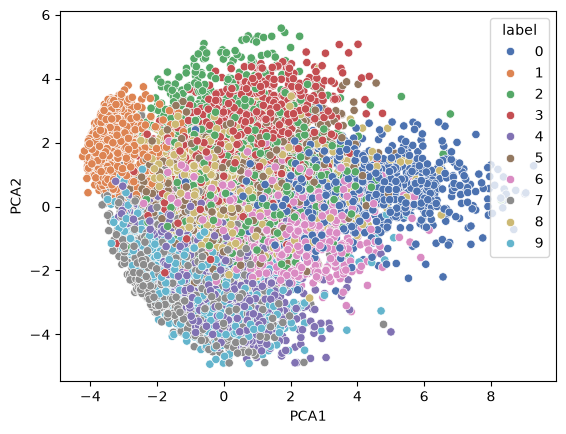

In [23]:
# Se genera la gráfica (Scatter) con Seaborn:
sns.scatterplot(
    data = df_pca,
    x = "PCA1", y = "PCA2",
    hue = "label",
    palette="deep"
)
plt.show()